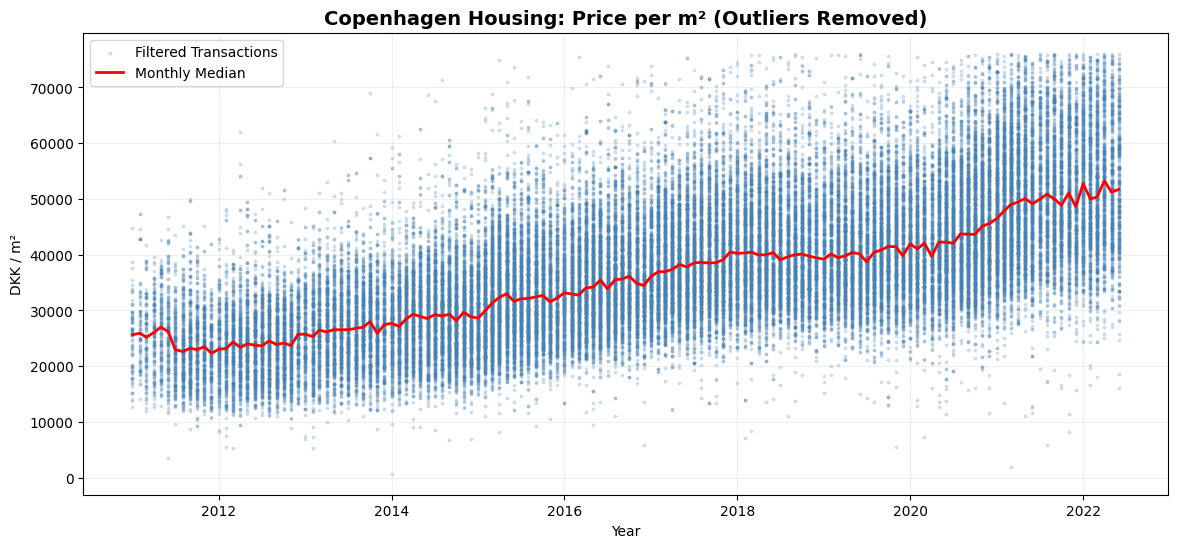

Removed transactions above 76,042 DKK/m²


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load and prep housing data
df = pd.read_csv('Housing_data_CPH_original.csv', sep=';', low_memory=False)
df['date'] = pd.to_datetime(df['Årmåned_salg'].astype(str), format='%Y%m', errors='coerce')
df['price_per_m2'] = df['tinglyst_pris'] / df['boligareal']

df = df.dropna(subset=['date', 'price_per_m2'])

# 99th percentile filter
threshold = df['price_per_m2'].quantile(0.99)
df_clean = df[df['price_per_m2'] <= threshold].sort_values('date')

# Plotting
plt.figure(figsize=(14, 6))
plt.scatter(df_clean['date'], df_clean['price_per_m2'], s=3, alpha=0.2, color='steelblue', label='Filtered Transactions')

# Monthly median line
median_trend = df_clean.groupby('date')['price_per_m2'].median()
plt.plot(median_trend.index, median_trend.values, color='red', lw=2, label='Monthly Median')

plt.title("Copenhagen Housing: Price per m² (Outliers Removed)", fontweight='bold', fontsize=14)
plt.xlabel("Year")
plt.ylabel("DKK / m²")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

print(f"Removed transactions above {threshold:,.0f} DKK/m²")

In [2]:
df['zip_code_name'].unique()

<StringArray>
[ 'København Ø',  'København S',     'Brønshøj',        'Valby',
      'Vanløse',      'Kastrup',  'København V', 'København NV',
  'København K',     'Hellerup', 'København SV',      'Rødovre',
     'Nordhavn',  'København N']
Length: 14, dtype: str